In [1]:

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
plt.rcParams['font.size'] = 10
plt.rcParams['axes.linewidth'] = 0.8
plt.rcParams['grid.alpha'] = 0.3

In [3]:
data = {
    'NLU': {
        'intra_dataset': {  # ArabicMMLU
            'AceGPT-7B': {'Base': [37.51, 31.23, 31.41, 39.10, 36.52], 
                         'Chat': [47.10, 28.26, 31.83, 42.54, 40.72],
                         'Tuned': [56.24, 51.54, 43.63, 56.79, 54.60]},
            'LLaMA3.1-8B': {'Base': [48.74, 29.60, 31.74, 46.32, 43.34],
                            'Instruct': [54.64, 28.96, 32.92, 53.27, 50.34],
                            'Tuned': [57.25, 54.75, 51.13, 56.77, 56.98]}
        },
        'intra_task': {  # ArabicMMLU → Belebele
            'AceGPT-7B': {'Base': [35.67, 24.00, 32.78, 26.33, 22.78],
                         'Chat': [39.67, 27.22, 42.56, 39.89, 26.00],
                         'Tuned': [43.78, 30.00, 46.56, 44.78, 40.00]},
            'LLaMA3.1-8B': {'Base': [52.89, 26.22, 50.11, 49.11, 45.00],
                            'Instruct': [58.67, 22.56, 57.56, 53.56, 52.67],
                            'Tuned': [58.56, 35.44, 56.00, 56.56, 57.00]}
        }
    },
    'NLI': {
        'intra_dataset': {  # ArEntail
            'AceGPT-7B': {'Base': [51.5, 50.8, 50.0, 50.0, 51.9],
                         'Chat': [50.0, 52.7, 50.0, 50.0, 51.0],
                         'Tuned': [82.9, 77.1, 64.4, 74.9, 79.2]},
            'LLaMA3.1-8B': {'Base': [50.6, 50.2, 51.6, 50.0, 51.0],
                            'Instruct': [56.3, 73.4, 64.6, 50.6, 65.9],
                            'Tuned': [90.3, 91.1, 91.6, 91.9, 90.5]}
        },
        'intra_task': {  # ArEntail → ArabicTE
            'AceGPT-7B': {'Base': [44.08, 57.35, 49.53, 49.76, 52.13],
                         'Chat': [50.24, 59.24, 47.16, 52.13, 55.45],
                         'Tuned': [60.19, 52.13, 66.59, 52.13, 53.08]},
            'LLaMA3.1-8B': {'Base': [51.66, 53.79, 52.13, 52.13, 52.13],
                            'Instruct': [52.84, 53.32, 52.37, 56.40, 55.45],
                            'Tuned': [58.06, 52.13, 55.45, 54.03, 56.40]}
        }
    },
    'Dialect': {
        'intra_dataset': {  # AraBench
            'AceGPT-7B': {'Base': [21.86, 14.59, 13.08, 21.07, 13.08],
                         'Chat': [20.89, 14.79, 14.48, 15.87, 13.08],
                         'Tuned': [45.12, 45.82, 39.84, 51.46, 27.25]},
            'LLaMA3.1-8B': {'Base': [15.69, 20.12, 14.46, 14.31, 13.02],
                            'Instruct': [15.81, 25.36, 14.37, 14.24, 13.02],
                            'Tuned': [88.39, 89.05, 89.24, 89.19, 88.91]}
        },
        'intra_task': {  # AraBench → Arabic Dialects Dataset
            'AceGPT-7B': {'Base': [17.64, 16.13, 19.88, 16.87, 16.13],
                         'Chat': [17.72, 16.13, 16.41, 19.09, 16.13],
                         'Tuned': [52.62, 44.38, 26.03, 20.96, 43.21]},
            'LLaMA3.1-8B': {'Base': [23.06, 16.13, 18.07, 19.71, 16.13],
                            'Instruct': [44.87, 16.13, 23.54, 30.99, 16.13],
                            'Tuned': [37.98, 19.50, 28.50, 26.70, 23.24]}
        }
    },
    'Sarcasm': {
        'intra_dataset': {  # ArSarcasm-v2
            'AceGPT-7B': {'Base': [72.63, 72.63, 72.63, 72.17, 71.07],
                         'Chat': [72.63, 72.63, 72.63, 72.63, 72.63],
                         'Tuned': [77.50, 78.57, 78.03, 78.27, 77.77]},
            'LLaMA3.1-8B': {'Base': [72.63, 72.63, 72.63, 69.50, 72.50],
                            'Instruct': [72.63, 43.57, 72.63, 72.60, 72.63],
                            'Tuned': [79.07, 78.13, 78.27, 75.60, 78.70]}
        },
        'intra_task': {  # ArSarcasm → iSarcasmEval
            'AceGPT-7B': {'Base': [14.29, 29.14, 85.64, 85.71, 85.36],
                         'Chat': [14.29, 14.43, 85.71, 85.71, 19.29],
                         'Tuned': [16.00, 15.93, 85.50, 85.64, 86.86]},
            'LLaMA3.1-8B': {'Base': [14.29, 16.00, 85.43, 85.71, 85.71],
                            'Instruct': [28.79, 14.29, 85.71, 85.64, 85.71],
                            'Tuned': [14.29, 14.29, 85.71, 85.29, 85.79]}
        }
    },
    'Translation': {
        'intra_dataset': {  # OPUS-100
            'AceGPT-7B': {'Base': [7.96, 6.88, 9.04, 2.05, 2.10],
                         'Chat': [8.87, 9.46, 9.78, 9.54, 7.63],
                         'Tuned': [16.56, 16.05, 16.19, 16.49, 16.03]},
            'LLaMA3.1-8B': {'Base': [8.74, 8.02, 8.13, 4.68, 3.42],
                            'Instruct': [8.11, 9.69, 8.98, 9.07, 3.20],
                            'Tuned': [14.26, 14.35, 13.81, 13.66, 14.05]}
        },
        'intra_task': {  # OPUS-100 → Tatoeba
            'AceGPT-7B': {'Base': [6.13, 16.15, 15.10, 13.18, 10.75],
                         'Chat': [9.68, 16.69, 16.71, 16.01, 16.41],
                         'Tuned': [14.97, 13.18, 10.48, 13.13, 13.03]},
            'LLaMA3.1-8B': {'Base': [0.17, 14.56, 14.18, 14.55, 10.77],
                            'Instruct': [1.20, 14.76, 13.90, 14.62, 15.07],
                            'Tuned': [7.60, 10.30, 10.67, 10.34, 10.56]}
        }
    },
    'Summarization': {
        'intra_dataset': {  # XLSUM
            'AceGPT-7B': {'Base': [0.74, 0.58, 0.47, 0.61, 3.58],
                         'Chat': [1.14, 0.65, 0.25, 0.64, 0.38],
                         'Tuned': [7.15, 7.19, 7.17, 7.19, 10.87]},
            'LLaMA3.1-8B': {'Base': [0.39, 0.32, 0.06, 0.36, 0.98],
                            'Instruct': [0.54, 0.40, 0.04, 0.35, 1.11],
                            'Tuned': [5.82, 5.76, 5.81, 5.78, 8.66]}
        },
        'intra_task': {  # XLSUM → AraSum
            'AceGPT-7B': {'Base': [0.61, 1.10, 2.96, 0.85, 0.67],
                         'Chat': [0.04, 0.07, 3.68, 0.57, 0.47],
                         'Tuned': [5.99, 6.04, 5.25, 5.24, 6.02]},
            'LLaMA3.1-8B': {'Base': [0.31, 0.32, 0.08, 0.83, 0.65],
                            'Instruct': [1.20, 0.92, 2.33, 1.10, 1.83],
                            'Tuned': [5.48, 6.34, 5.35, 4.95, 5.36]}
        }
    }
}

In [4]:
def create_stacked_bar_charts(figsize=(18, 7)):
    """Create unified stacked bar chart with incremental differences from lowest to highest"""
    
    fig, ax = plt.subplots(1, 1, figsize=figsize)
    
    # Define colors for progression (light to dark) - slightly refined
    colors = {
        'AceGPT-7B': ['#FFE6E8', '#FF6B6B', '#D63031'],  # Light to dark red
        'LLaMA3.1-8B': ['#E6F3FF', '#42A5F5', '#1976D2']  # Light to dark blue
    }
    
    # Define different patterns/styles for intra-dataset vs intra-task
    patterns = {
        'intra_dataset': '',  # Solid fill
        'intra_task': '///'   # Diagonal hatching
    }
    
    tasks = list(data.keys())
    models = ['AceGPT-7B', 'LLaMA3.1-8B']
    conditions = ['intra_dataset', 'intra_task']
    
    # Calculate total number of bars (2 models × 2 conditions × 6 tasks)
    total_bars = len(models) * len(conditions) * len(tasks)
    bar_width = 0.5  # Made thinner
    
    # Create x positions for each bar
    x_positions = []
    x_labels_tasks = []
    
    bar_idx = 0
    for task_idx, task in enumerate(tasks):
        task_start = bar_idx
        for model_idx, model in enumerate(models):
            for cond_idx, condition in enumerate(conditions):
                x_positions.append(bar_idx)
                bar_idx += 1
        
        # Add task label (centered for this task's bars) - change NLU to MCQ
        task_display = task.replace('NLU', 'MCQ')
        task_center = (task_start + bar_idx - 1) / 2
        x_labels_tasks.append((task_center, task_display))
    
    # Process each bar
    for pos_idx, x_pos in enumerate(x_positions):
        # Determine which task, model, and condition this bar represents
        task_idx = pos_idx // (len(models) * len(conditions))
        remaining = pos_idx % (len(models) * len(conditions))
        model_idx = remaining // len(conditions)
        cond_idx = remaining % len(conditions)
        
        task = tasks[task_idx]
        model = models[model_idx]
        condition = conditions[cond_idx]
        
        # Calculate average performance for each variant
        performance_data = {}
        for variant_key, values in data[task][condition][model].items():
            performance_data[variant_key] = np.mean(values)
        
        # Sort variants by performance (lowest to highest)
        variant_keys = list(performance_data.keys())
        sorted_variants = sorted(variant_keys, key=lambda x: performance_data[x])
        
        # Get the highest performance value for top label
        highest_performance = max(performance_data.values())
        
        # Create stacked segments with incremental differences
        bottom = 0
        for stack_idx, variant in enumerate(sorted_variants):
            current_perf = performance_data[variant]
            
            if stack_idx == 0:
                # First segment: use actual value as height
                height = current_perf
            else:
                # Subsequent segments: use difference from previous
                prev_variant = sorted_variants[stack_idx - 1]
                prev_perf = performance_data[prev_variant]
                height = current_perf - prev_perf
            
            # Determine color based on original variant type
            if variant == 'Base':
                color_idx = 0
            elif variant in ['Chat', 'Instruct']:
                color_idx = 1
            else:  # Tuned
                color_idx = 2
            
            color = colors[model][color_idx]
            pattern = patterns[condition]
            
            # Create bar segment with subtle edge styling
            bar = ax.bar(x_pos, height, bar_width, bottom=bottom, 
                        color=color, alpha=0.85, edgecolor='white', linewidth=0.8,
                        hatch=pattern)
            
            bottom += height
        
        # Add the highest value on top of each bar
        ax.text(x_pos, bottom + highest_performance * 0.01, f'{highest_performance:.1f}', 
               ha='center', va='bottom', fontsize=10, fontweight='bold', color='#333333')
    
    # Customize axes with refined styling
    ax.set_xticks(x_positions)
    ax.set_xticklabels([])  # Clean x-axis
    ax.set_yticklabels([])
    ax.set_yticks([])
    ax.set_ylabel('Performance', fontsize=14, fontweight='bold')
    # ax.grid(True, alpha=0.2, axis='y', linestyle='-', linewidth=0.25)
    ax.set_axisbelow(True)
    
    # Refined axis styling
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_color('#666666')
    
    # Task names (single row, centered under each task group)
    for task_center, task_name in x_labels_tasks:
        ax.text(task_center, -ax.get_ylim()[1] * 0.03, task_name, 
               ha='center', va='top', fontsize=12, fontweight='bold', color='#333333')
    
    # Add elegant separators between tasks
    for task_idx in range(1, len(tasks)):
        separator_x = task_idx * len(models) * len(conditions) - 0.5
        ax.axvline(x=separator_x, color='#CCCCCC', linewidth=1.5, alpha=0.8)
    
    # Add vertical divider between translation & summarization tasks and other tasks
    # Assuming translation and summarization are the last two tasks
    major_divider_x = 4 * len(models) * len(conditions) - 0.5
    ax.axvline(x=major_divider_x, color="#000F02", linewidth=4, alpha=0.8)
    
    # Add task category labels at the top
    ylim_top = ax.get_ylim()[1]
    # Left section: answer-choice-based tasks
    left_section_center = (4 * len(models) * len(conditions) - 1) / 2
    ax.text(left_section_center, ylim_top * 1.05, 'Answer Choices Tasks', 
           ha='center', va='bottom', fontsize=13, fontweight='bold', color='#333333',
           bbox=dict(boxstyle="round,pad=0.3", facecolor="#FFFFFF", alpha=0.7))
    
    # Right section: open-ended generation tasks
    right_section_start = 4 * len(models) * len(conditions)
    right_section_end = len(tasks) * len(models) * len(conditions)
    right_section_center = (right_section_start + right_section_end - 1) / 2
    ax.text(right_section_center, ylim_top * 1.05, 'Open-Ended Generation Tasks', 
           ha='center', va='bottom', fontsize=13, fontweight='bold', color='#333333',
           bbox=dict(boxstyle="round,pad=0.3", facecolor="#FFFFFF", alpha=0.7))
    
    # Subtle separators between model groups within tasks
    for task_idx in range(len(tasks)):
        for model_idx in range(1, len(models)):
            separator_x = task_idx * len(models) * len(conditions) + model_idx * len(conditions) - 0.5
            ax.axvline(x=separator_x, color='#E8E8E8', linewidth=1, alpha=0.6)
    
    # Create refined legend with organized columns
    legend_elements = []
    
    # Column 1: AceGPT variants
    for variant_idx, variant_name in enumerate(['Base', 'Chat/Instruct', 'Tuned']):
        legend_elements.append(plt.Rectangle((0, 0), 1, 1, facecolor=colors['AceGPT-7B'][variant_idx], 
                                           edgecolor='white', linewidth=0.8, alpha=0.85,
                                           label=f'AceGPT {variant_name}'))
    
    # Column 2: LLaMA variants
    for variant_idx, variant_name in enumerate(['Base', 'Chat/Instruct', 'Tuned']):
        legend_elements.append(plt.Rectangle((0, 0), 1, 1, facecolor=colors['LLaMA3.1-8B'][variant_idx], 
                                           edgecolor='white', linewidth=0.8, alpha=0.85,
                                           label=f'LLaMA {variant_name}'))
    
    # Column 3: Condition patterns
    legend_elements.append(plt.Rectangle((0, 0), 1, 1, facecolor='#888888', alpha=0.6,
                                       edgecolor='white', linewidth=0.8,
                                       label='Intra-Dataset'))
    legend_elements.append(plt.Rectangle((0, 0), 1, 1, facecolor='#888888', alpha=0.6, 
                                       hatch='///', edgecolor='white', linewidth=0.8,
                                       label='Intra-Task'))
    
    # Elegant legend placement with organized columns
    fig.legend(handles=legend_elements, loc='lower center', bbox_to_anchor=(0.5, -0.03), 
              ncol=3, fontsize=12, frameon=True, fancybox=True, shadow=False,
              edgecolor='#CCCCCC', facecolor='#FAFAFA',
              columnspacing=2.0)  # Add spacing between columns
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.88, bottom=0.18)  # Adjusted top margin for category labels
    
    return fig

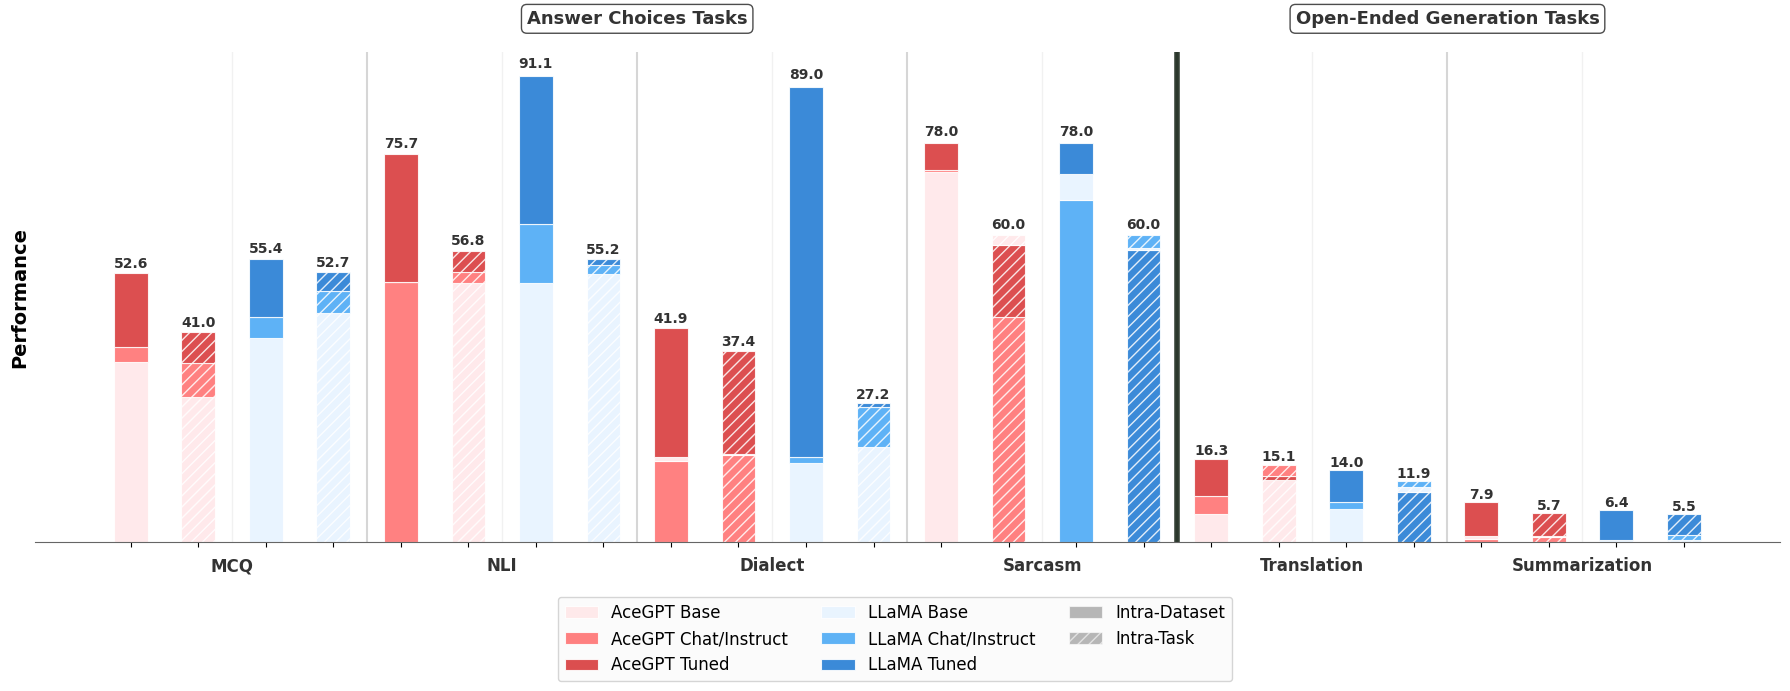

In [5]:
plot = create_stacked_bar_charts()
plt.savefig('Notebooks/results_visualization/stacked_bar_chart.pdf', dpi=300, bbox_inches='tight',format='pdf')
plt.show()